Load Required Libraries


In [2]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("results", exist_ok=True)

Load the Single-Cell Dataset

In [4]:
data = pd.read_csv("C:\\Users\\laksh\\Downloads\\rnaseq\\GSM2230761_mouse1_umifm_counts.csv")
data.head()

,Unnamed: 0,barcode,assigned_cluster,0610007P14Rik,0610009B22Rik,0610009E02Rik,0610009L18Rik,0610009O20Rik,0610010F05Rik,0610010K14Rik,...,Zw10,Zwilch,Zwint,Zxdb,Zxdc,Zyg11b,Zyx,Zzef1,Zzz3,l7Rn6
0,mouse1_lib1.final_cell_0001,AAGTGAAAG-CGACTCCT,beta,0,0,0,0,0,2,0,...,0,0,1,0,0,0,0,1,0,1
1,mouse1_lib1.final_cell_0002,TGCAAGGG-GGCATGCT,ductal,2,0,0,0,0,1,0,...,0,0,1,0,0,0,1,0,0,1
2,mouse1_lib1.final_cell_0003,GAGAGCCCAT-CTTCTGGA,delta,0,0,1,0,0,0,0,...,0,0,0,0,1,0,0,1,0,2
3,mouse1_lib1.final_cell_0004,AAATCAGA-GTTGCACG,schwann,0,0,0,0,1,0,0,...,1,0,1,0,0,1,2,0,0,3
4,mouse1_lib1.final_cell_0005,GAGGCGTTAG-GGCTACTA,delta,1,1,0,0,0,0,0,...,0,0,1,0,0,0,0,1,1,0


Extract Gene Expression Matrix and Metadata

In [9]:
gene_expression = data.iloc[:, 3:]
cell_types = data["assigned_cluster"]
barcodes = data["barcode"]

gene_expression.head()

,0610007P14Rik,0610009B22Rik,0610009E02Rik,0610009L18Rik,0610009O20Rik,0610010F05Rik,0610010K14Rik,0610011F06Rik,0610012G03Rik,0610025J13Rik,...,Zw10,Zwilch,Zwint,Zxdb,Zxdc,Zyg11b,Zyx,Zzef1,Zzz3,l7Rn6
0,0,0,0,0,0,2,0,1,0,0,...,0,0,1,0,0,0,0,1,0,1
1,2,0,0,0,0,1,0,1,1,0,...,0,0,1,0,0,0,1,0,0,1
2,0,0,1,0,0,0,0,1,2,0,...,0,0,0,0,1,0,0,1,0,2
3,0,0,0,0,1,0,0,0,0,0,...,1,0,1,0,0,1,2,0,0,3
4,1,1,0,0,0,0,0,0,1,0,...,0,0,1,0,0,0,0,1,1,0


Convert Data to AnnData Format

In [10]:
adata = sc.AnnData(gene_expression.values)

adata.obs["cell_type"] = cell_types.values
adata.obs["barcode"] = barcodes.values

adata

AnnData object with n_obs × n_vars = 822 × 14878
    obs: 'cell_type', 'barcode'

Calculate Quality Control Metrics

In [11]:
sc.pp.calculate_qc_metrics(adata, inplace=True)

Visualize QC Metrics

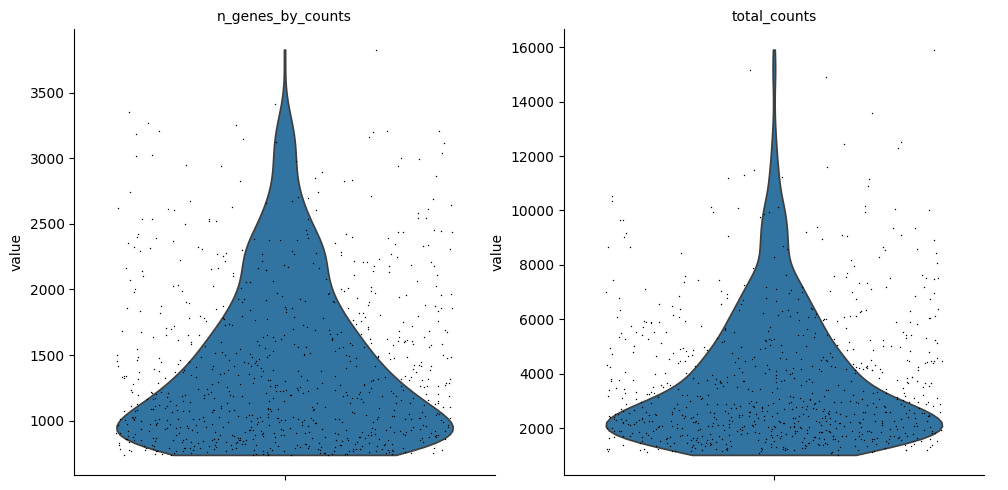

<Figure size 640x480 with 0 Axes>

In [12]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts"],
    jitter=0.4,
    multi_panel=True
)

plt.savefig("results/QC_violin.png")

Filter Low Quality Cells and Genes

In [13]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

Normalize Gene Expression Data

In [14]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

Identify Highly Variable Genes

In [15]:
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=2000,
    subset=True,
    flavor="seurat"
)

Scale the Data

In [16]:
sc.pp.scale(adata, max_value=10)

Perform Principal Component Analysis (PCA)

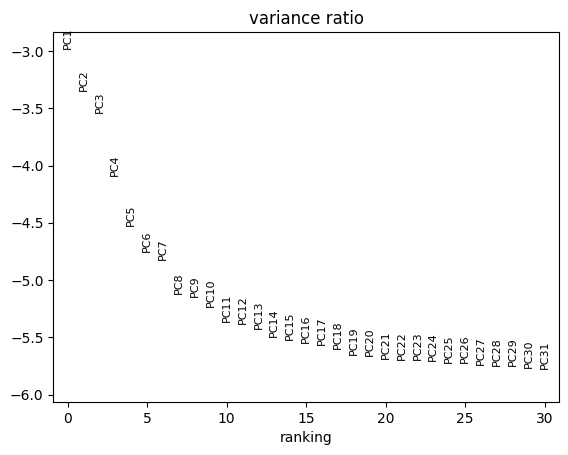

<Figure size 640x480 with 0 Axes>

In [17]:
sc.tl.pca(adata)

sc.pl.pca_variance_ratio(adata, log=True)

plt.savefig("results/PCA_variance.png")

Compute Neighborhood Graph

In [18]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=30)

Generate UMAP Visualization

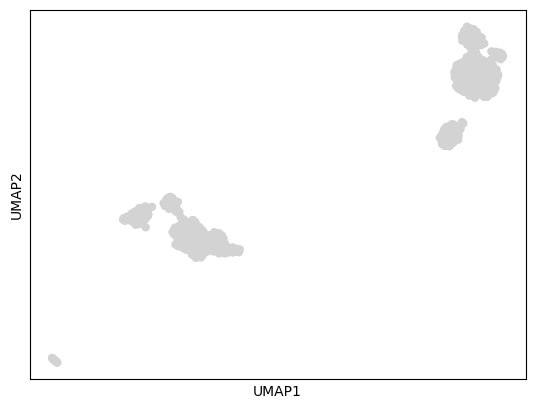

<Figure size 640x480 with 0 Axes>

In [19]:
sc.tl.umap(adata)

sc.pl.umap(adata)

plt.savefig("results/UMAP.png")

Perform Leiden Clustering

C:\Users\laksh\AppData\Local\Temp\ipykernel_23120\376280957.py:1: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata)


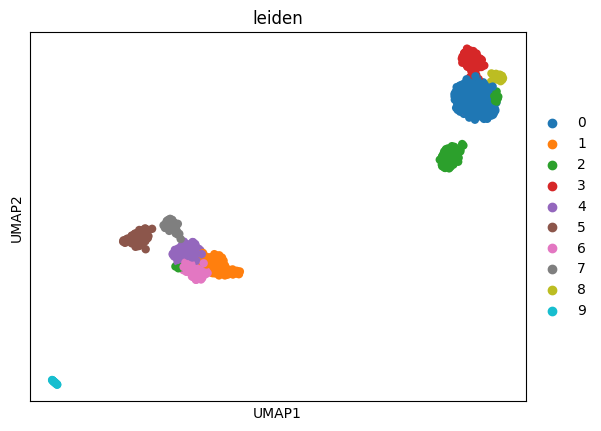

<Figure size 640x480 with 0 Axes>

In [20]:
sc.tl.leiden(adata)

sc.pl.umap(adata, color="leiden")

plt.savefig("results/UMAP_clusters.png")

Identify Marker Genes

C:\Users\laksh\AppData\Roaming\Python\Python313\site-packages\scanpy\tools\_rank_genes_groups.py:483: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\laksh\AppData\Roaming\Python\Python313\site-packages\scanpy\tools\_rank_genes_groups.py:483: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\laksh\AppData\Roaming\Python\Python313\site-packages\scanpy\tools\_rank_genes_groups.py:483: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\laksh\AppData\Roaming\Python\Python313\site-packages\scanpy\tools\_rank_genes_groups.py:483: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\laksh\AppData\Roaming\Python\Python313\site-packages\scanpy\tools\_rank_genes_groups.py:483: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name,

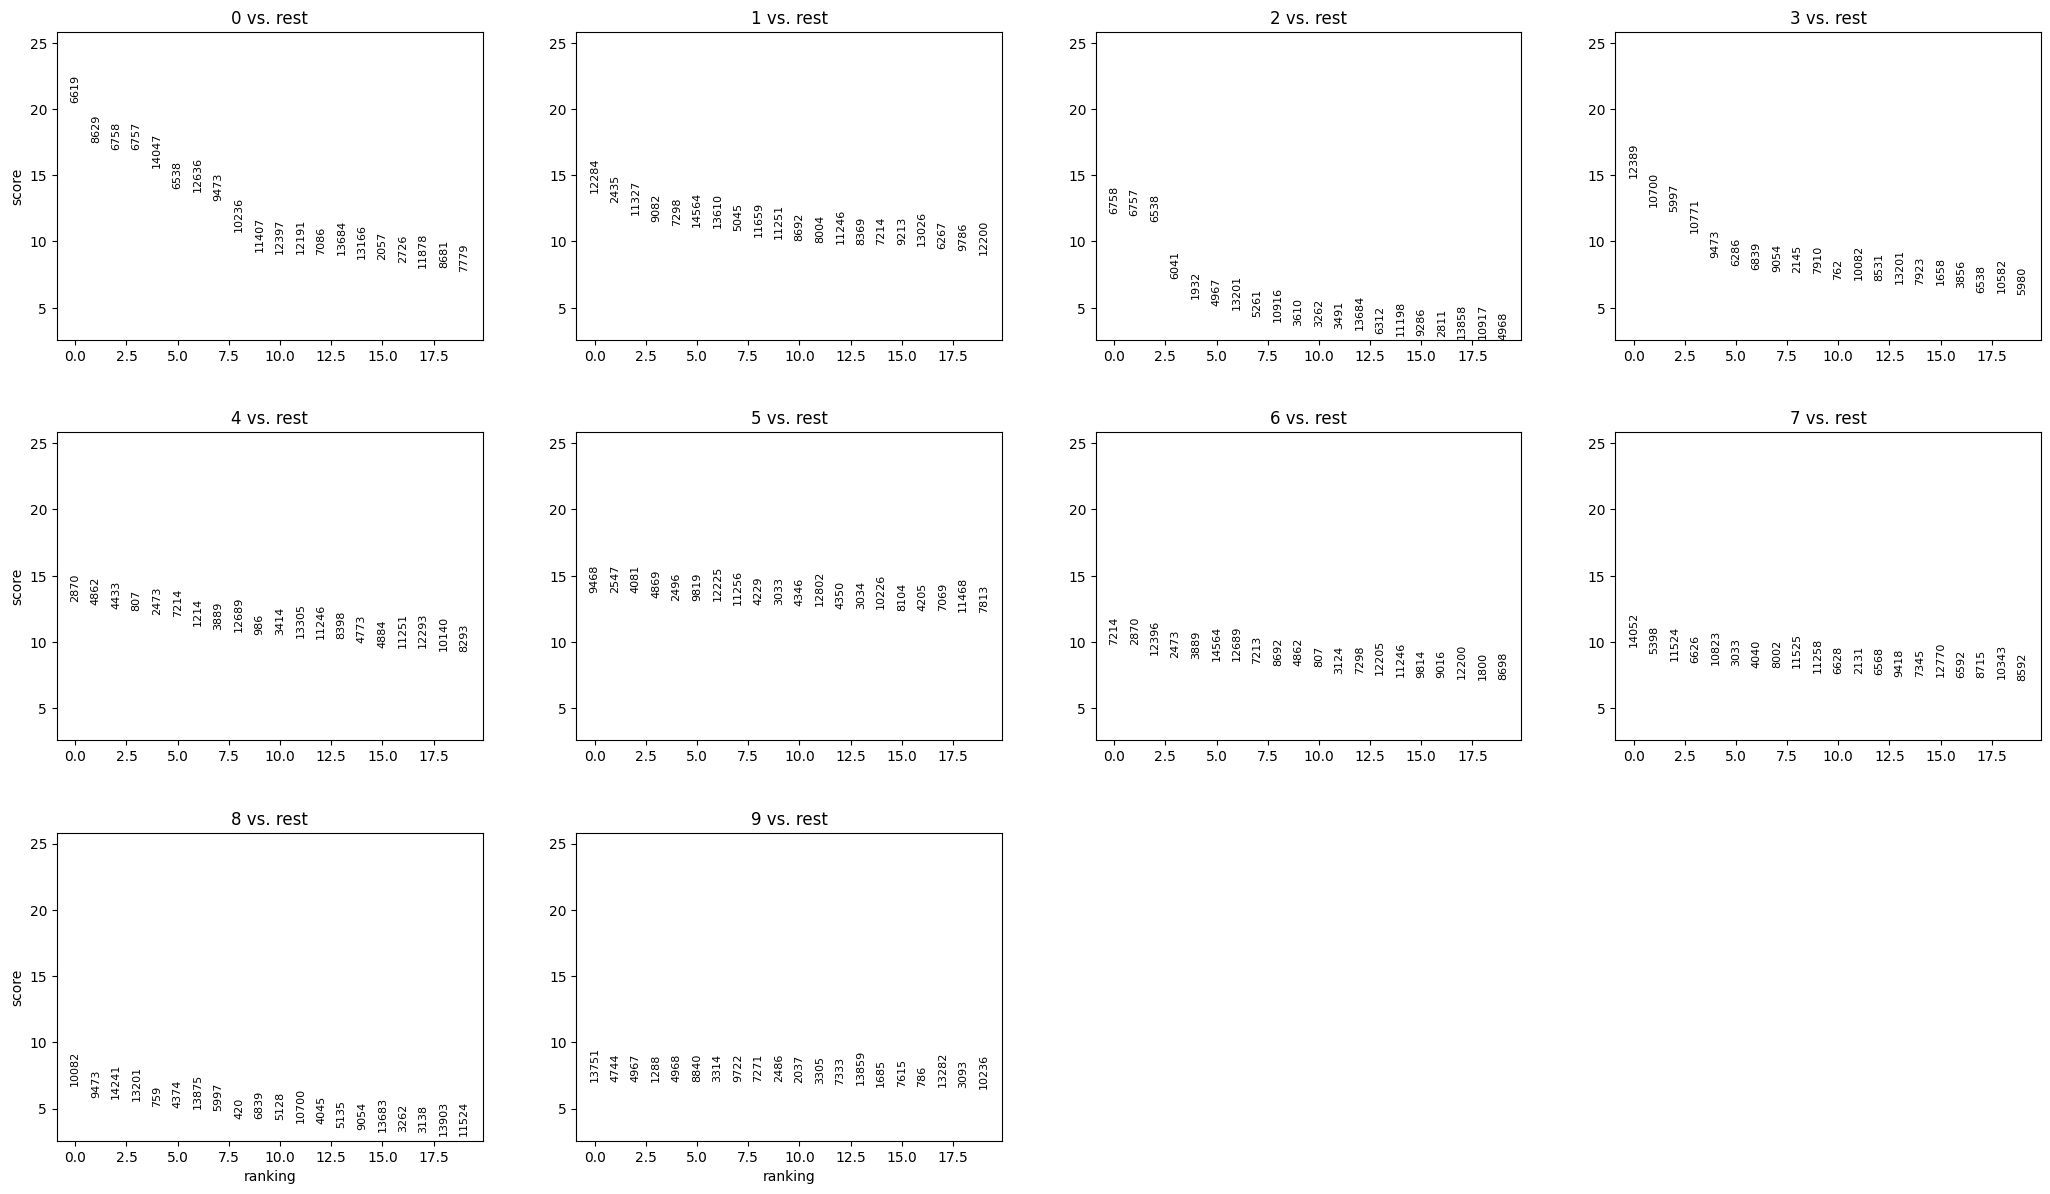

<Figure size 640x480 with 0 Axes>

In [21]:
sc.tl.rank_genes_groups(adata, "leiden", method="wilcoxon")

sc.pl.rank_genes_groups(adata)

plt.savefig("results/marker_genes.png")

Visualize Marker Genes with Heatmap

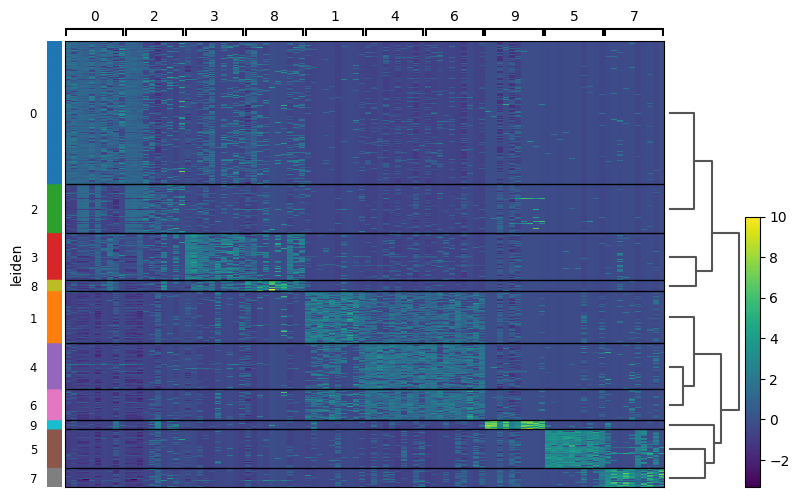

<Figure size 640x480 with 0 Axes>

In [22]:
sc.pl.rank_genes_groups_heatmap(
    adata,
    n_genes=10,
    groupby="leiden"
)

plt.savefig("results/marker_heatmap.png")

In [24]:
adata.write("results/scRNA_processed.h5ad")